In [16]:
import json
import numpy as np
import matplotlib.pyplot as plt
from src.utils.plotting_style import set_figure_size

In [19]:
with open('si_lookahead_finding_14.json', 'r') as f:
    si_results = json.load(f)

with open('fisher_lookahead_finding_14.json', 'r') as f:
    fisher_results = json.load(f)

with open('si_finding_14.json', 'r') as f:
    si_results_no = json.load(f)

with open('fisher_finding_14.json', 'r') as f:
    fisher_results_no = json.load(f)

with open('fisher_performance_baseline_15.json', 'r') as f:
    fisher_baseline = json.load(f)

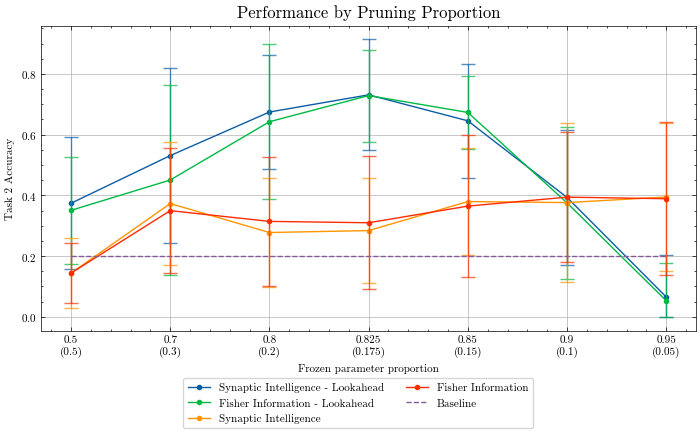

In [44]:
fig, ax = plt.subplots()

x = sorted(si_results.keys())
si_y = [np.mean(si_results[key]) for key in x]
si_yerr = [np.std(si_results[key]) for key in x]
fisher_y = [np.mean(fisher_results[key]) for key in x]
fisher_yerr = [np.std(fisher_results[key]) for key in x]
si_y_no = [np.mean(si_results_no[key]) for key in x]
si_yerr_no = [np.std(si_results_no[key]) for key in x]
fisher_y_no = [np.mean(fisher_results_no[key]) for key in x]
fisher_yerr_no = [np.std(fisher_results_no[key]) for key in x]

baseline_y = [np.mean(fisher_baseline["0.825"]) for _ in x]
baseline_yerr = [np.std(fisher_baseline["0.825"]) for key in x]

# Create the plot
ax.errorbar(x, si_y, yerr=[np.minimum(si_y, si_yerr), si_yerr], capsize=5, color='C0', fmt='none', alpha=0.7)
ax.plot(x, si_y, 'o-', color='C0', label="Synaptic Intelligence - Lookahead")
ax.errorbar(x, fisher_y, yerr=[np.minimum(fisher_y, fisher_yerr), fisher_yerr], fmt='none', capsize=5, color='C1', alpha=0.7)
ax.plot(x, fisher_y, 'o-', color='C1', label="Fisher Information - Lookahead")
ax.errorbar(x, si_y_no, yerr=[np.minimum(si_y_no, si_yerr_no), si_yerr_no], capsize=5, color='C2', fmt='none', alpha=0.7)
ax.plot(x, si_y_no, 'o-', color='C2', label="Synaptic Intelligence")
ax.errorbar(x, fisher_y_no, yerr=[np.minimum(fisher_y_no, fisher_yerr_no), fisher_yerr_no], fmt='none', capsize=5, color='C3', alpha=0.7)
ax.plot(x, fisher_y_no, 'o-', color='C3', label="Fisher Information")
# ax.errorbar(x, baseline_y, yerr=[np.minimum(baseline_y, baseline_yerr), baseline_yerr], fmt='none', capsize=5, color='C4', alpha=0.7)
ax.plot(x, baseline_y, linestyle='--', marker='none', color='C4', label="Baseline")

ax.set_xticks(x)
current_ticks = ax.get_xticks()
new_labels = [f'{tick}\n({1-float(tick):.3g})' for tick in x]
ax.set_xticklabels(new_labels)

plt.xlabel("Frozen parameter proportion")
plt.ylabel("Task 2 Accuracy")
plt.title("Performance by Pruning Proportion", fontsize=12)
ax.grid(True)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, -0.15)
)

set_figure_size(fig)
fig.savefig("figures/lookahead_finding.pdf", dpi=300)

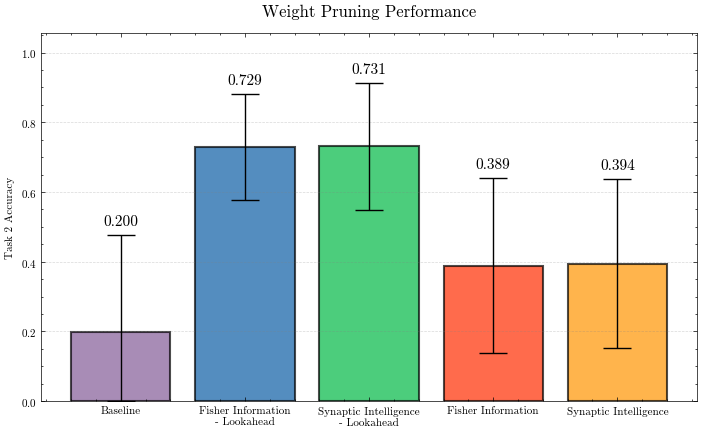

In [45]:
BEST_PRUNING_PROP = 0.825
BEST_NO_LOOKAHEAD = 0.95

prev_perf = fisher_baseline[f"{BEST_PRUNING_PROP}"]
fisher_perf = fisher_results[f"{BEST_PRUNING_PROP}"]
si_perf = si_results[f"{BEST_PRUNING_PROP}"]
fisher_perf_no = fisher_results_no[f"{BEST_NO_LOOKAHEAD}"]
si_perf_no = si_results_no[f"{BEST_NO_LOOKAHEAD}"]

prev_acc = np.array(prev_perf).mean()
prev_std = np.array(prev_perf).std()
new_acc = np.array(fisher_perf).mean()
new_std = np.array(fisher_perf).std()
si_acc = np.array(si_perf).mean()
si_std = np.array(si_perf).std()
fisher_acc_no = np.array(fisher_perf_no).mean()
fisher_std_no = np.array(fisher_perf_no).std()
si_acc_no = np.array(si_perf_no).mean()
si_std_no = np.array(si_perf_no).std()

# 2. Create a prettier plot
# Use a more balanced figure size
fig, ax = plt.subplots()

# Define some nice colors
colors = ["C4", "C0", "C1", "C3", "C2"]  # Steel Blue and a nice Green

# Plot the bars with improved styling
bars = ax.bar(
    x=["Baseline", "Fisher Information\n- Lookahead", "Synaptic Intelligence\n- Lookahead", "Fisher Information", "Synaptic Intelligence"],
    height=[prev_acc, new_acc, si_acc, fisher_acc_no, si_acc_no],
    yerr=[[np.minimum(prev_acc, prev_std), np.minimum(new_acc, new_std), np.minimum(si_acc, si_std), np.minimum(fisher_acc_no, fisher_std_no), np.minimum(si_acc_no, si_std_no)], [prev_std, new_std, si_std, fisher_std_no, si_std_no]],
    color=colors,
    alpha=0.7,  # Make bars slightly transparent
    edgecolor="black",  # Add a crisp black edge
    capsize=10,  # THIS IS KEY: Adds caps to the error bars
    ecolor="black",  # Color of the error bar lines
    linewidth=1.5,
)

# 3. Add Labels, Title, and Grid for context
ax.set_ylabel("Task 2 Accuracy")
ax.set_title("Weight Pruning Performance", fontsize=12, pad=12)
# ax.set_xticks(ticks=[0, 1], labels=["Baseline", "Lookahead Pruning"], fontsize=12)

# Add a subtle horizontal grid to make comparisons easier
ax.yaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.3)

# Set a dynamic Y-axis limit for better spacing
ax.set_ylim(0, max(new_acc, prev_acc) + max(new_std, prev_std) + 0.05)

# 4. Add data labels on top of the bars
# This shows the exact mean value on the plot
ax.bar_label(bars, fmt="{:.3f}", padding=5, fontsize=11, color="black")

# Ensure everything fits without overlapping
plt.tight_layout()

set_figure_size(fig)

plt.savefig("figures/lookahead_performance.pdf", dpi=300)
plt.show()

In [63]:
import pandas as pd

# --- Define your fine-tuned results ---
finetuned_data = {
    "Model": [
        "baseline",
        "si_lookahead",
        "fisher_lookahead",
        "fisher_no",
        "si_no",
    ],
    "tweets_hate_speech_detection": [
        "0.94(0.92)/0.72(0.83)[0.81]",
        "0.93(0.91)/0.75(0.82)[0.82]",
        "0.93(0.91)/0.73(0.81)[0.81]",
        "0.93(0.91)/0.73(0.83)[0.77]",
        "0.93(0.91)/0.73(0.83)[0.77]"
    ],
    "civil_comments": [
        "0.94(0.93)/0.82(0.82)[0.86]",
        "0.94(0.93)/0.82(0.82)[0.93]",
        "0.94(0.93)/0.82(0.82)[0.93]",
        "0.94(0.93)/0.82(0.82)[0.82]",
        "0.94(0.93)/0.82(0.82)[0.82]"
    ],
    "hatemoji": [
        "0.93(0.94)/0.74(0.8)[0.77]",
        "0.93(0.94)/0.76(0.81)[0.83]",
        "0.93(0.95)/0.75(0.8)[0.8]",
        "0.93(0.94)/0.74(0.81)[0.77]",
        "0.93(0.94)/0.74(0.8)[0.77]"
    ],
    "sbic": [
        "0.94(0.93)/0.71(0.71)[0.77]",
        "0.93(0.93)/0.73(0.73)[0.8]",
        "0.94(0.93)/0.71(0.71)[0.8]",
        "0.94(0.93)/0.71(0.71)[0.77]",
        "0.94(0.93)/0.71(0.71)[0.77]"
    ],
    "hatecheck": [
        "0.93(0.95)/0.7(0.8)[0.77]",
        "0.92(0.95)/0.71(0.81)[0.84]",
        "0.93(0.95)/0.7(0.81)[0.83]",
        "0.93(0.94)/0.7(0.8)[0.77]",
        "0.93(0.95)/0.69(0.8)[0.77]"
    ]
}

# --- Convert to DataFrame ---
finetuned_df = pd.DataFrame(finetuned_data)

# --- Reshape to long format ---
finetuned_long = finetuned_df.melt(id_vars="Model", var_name="Dataset", value_name="Finetuned_Score")

# --- Parser: extract the five metrics ---
def parse_finetuned_cell(cell):
    """
    Parses a string of the form:
    '0.93(0.91)/0.75(0.81)[0.71]' into:
    Jigsaw_Macro, Jigsaw_True, Task_Macro, Task_True, Certified_Macro
    """
    try:
        jigsaw_part, rest = cell.split('/')
        jigsaw_macro = float(jigsaw_part.split('(')[0])
        jigsaw_true = float(jigsaw_part.split('(')[1].rstrip(')'))

        task_part, certified_part = rest.split('[')
        task_macro = float(task_part.split('(')[0])
        task_true = float(task_part.split('(')[1].rstrip(')'))

        certified_macro = float(certified_part.rstrip(']'))
        return pd.Series([jigsaw_macro, jigsaw_true, task_macro, task_true, certified_macro])
    except Exception as e:
        print(f"Error parsing cell: {cell} -> {e}")
        return pd.Series([None] * 5)

# --- Apply parsing function ---
finetuned_long[["Jigsaw_Macro", "Jigsaw_True", "Task_Macro", "Task_True", "Certified_Macro"]] = \
    finetuned_long["Finetuned_Score"].apply(parse_finetuned_cell)

# --- Drop the raw string column ---
finetuned_long.drop(columns="Finetuned_Score", inplace=True)

# `finetuned_long` is now ready for analysis or plotting
finetuned_long.head()

,Model,Dataset,Jigsaw_Macro,Jigsaw_True,Task_Macro,Task_True,Certified_Macro
0,baseline,tweets_hate_speech_detection,0.94,0.92,0.72,0.83,0.81
1,si_lookahead,tweets_hate_speech_detection,0.93,0.91,0.75,0.82,0.82
2,fisher_lookahead,tweets_hate_speech_detection,0.93,0.91,0.73,0.81,0.81
3,fisher_no,tweets_hate_speech_detection,0.93,0.91,0.73,0.83,0.77
4,si_no,tweets_hate_speech_detection,0.93,0.91,0.73,0.83,0.77


['tweets_hate_speech_detection', 'civil_comments', 'hatemoji', 'sbic', 'hatecheck']
0.72
0.82
0.74
0.71
0.7


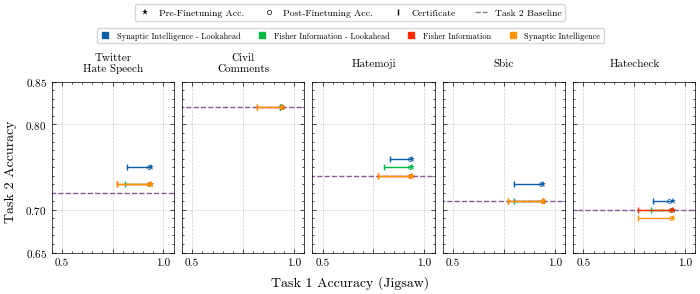

In [79]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

# Apply SciencePlots style
plt.style.use(["science", "no-latex", "scatter"])

# Use the cleaned finetuned DataFrame
models = finetuned_long["Model"].unique()
datasets = list(finetuned_long["Dataset"].unique())  # order preserved
print(datasets)

titles = {
    "tweets_hate_speech_detection": "Twitter\nHate Speech",
    "civil_comments": "Civil\nComments",
    "hatemoji": "Hatemoji",
    "sbic": "Sbic",
    "hatecheck": "Hatecheck",
}

# Provide Jigsaw baseline macro accuracy separately for plotting stars
baseline_jigsaw_macro = {
    "baseline": 0.94,
    "mxbai-embed-large-v1": 0.92,
    "m2-bert-80M-2k-retrieval": 0.86,
    "gte-large": 0.90,
    "voyage-3": 0.90,
}

# Plot for each dataset
fig, axs = plt.subplots(1, len(datasets), sharey=True, layout="constrained", gridspec_kw={"hspace": 0.0})

colors = ["C4", "C0", "C1", "C3", "C2"]
for i, dataset in enumerate(datasets):
    ax = axs[i]

    for j, (model, color) in enumerate(zip(models, colors)):
        row = finetuned_long[(finetuned_long["Model"] == model) & (finetuned_long["Dataset"] == dataset)]

        row = row.iloc[0]
        if model == "baseline":
            print(row["Task_Macro"])
            ax.plot([0, 2], [row["Task_Macro"], row["Task_Macro"]], color="C4", linestyle="--")
            continue
        baseline_macro = baseline_jigsaw_macro["baseline"]

        # Line connecting baseline, finetuned, certified
        x_vals = [baseline_macro, row["Jigsaw_Macro"], row["Certified_Macro"]]
        y_vals = [row["Task_Macro"]] * 3
        ax.plot(x_vals, y_vals, color=color, linestyle="-", marker="none")

        # Markers
        # ax.scatter(baseline_macro, row["Task_Macro"], color=color, marker="*", s=2)  # baseline
        # ax.scatter(row["Jigsaw_Macro"], row["Task_Macro"], color=color, facecolors="none", marker="o", s=2)  # finetuned
        # ax.scatter(row["Certified_Macro"], row["Task_Macro"], edgecolors=color, marker="o", s=2)  # certified
        ax.plot(
            row["Jigsaw_Macro"],
            row["Task_Macro"],
            color=color,
            marker="o",
            markersize=3,
            markeredgewidth=0.5,
            markerfacecolor="none",
        )  # finetuned
        ax.plot(
            baseline_macro,
            row["Task_Macro"],
            color=color,
            marker="*",
            markersize=5,
            markeredgewidth=0.0,
        )  # baseline
        ax.plot(
            row["Certified_Macro"],
            row["Task_Macro"],
            color=color,
            marker="|",
            markersize=5,
            # markerfacecolor="none",
            # markeredgewidth=0.5,
        )  # certified - hollow circle with thinner edge
        
    # Title and axes
    ax.set_title(titles[dataset], y=1.06, va="center", fontsize=8)
    ax.set_xlim(0.45, 1.05)
    ax.set_xticks([0.5, 0.75, 1.0], labels=["0.5", "", "1.0"])
    ax.set_yticks([0.65, 0.7, 0.8, 0.85])
    # ax.set_ylim(0.55, 0.85)
    ax.grid(True, linestyle="--", alpha=0.6)

import matplotlib.lines as mlines

model_names = {
    "baseline": "Baseline",
    "si_lookahead": "Synaptic Intelligence - Lookahead",
    "fisher_lookahead": "Fisher Information - Lookahead",
    "fisher_no": "Fisher Information",
    "si_no": "Synaptic Intelligence",
}

# Top row: model-color legend (simplified labels)
model_lines = []
for j, (model, color) in enumerate(zip(models, colors)):
    if model == "baseline":
        continue
    # Create a legend entry for each model
    model_lines.append(mlines.Line2D([0], [0], color=color, lw=0, marker="s", markersize=5, label=model_names[model]))


# Bottom row: marker types and dashed line
symbol_lines = [
    mlines.Line2D(
        [0],
        [0],
        marker="*",
        lw=0,
        color="black",
        markersize=5,
        markeredgewidth=0.0,
        label="Pre-Finetuning Acc.",
    ),
    mlines.Line2D(
        [0],
        [0],
        marker="o",
        markersize=3,
        lw=0,
        color="black",
        markeredgewidth=0.5,
        markerfacecolor="none",
        label="Post-Finetuning Acc.",
    ),
    mlines.Line2D([0], [0], marker="|", lw=0, color="black", markersize=5, label="Certificate"),
    mlines.Line2D([0], [0], linestyle="--", color="gray", label="Task 2 Baseline"),
]

# Combine both rows
full_legend = model_lines + symbol_lines

legend = fig.legend(
    handles=symbol_lines,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.2),  # position above the plot
    ncol=4,  # auto-wrap into two rows
    frameon=True,  # outline box
    handlelength=1.2,
    fontsize=7,
)

legend = fig.legend(
    handles=model_lines,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),  # position above the plot
    ncol=5,  # auto-wrap into two rows
    frameon=True,  # outline box
    fontsize=6,
    handlelength=1.2
)

fig.supxlabel("Task 1 Accuracy (Jigsaw)", fontsize=10)
fig.supylabel("Task 2 Accuracy", fontsize=10)

# Legend: only one color entry per model
# custom_lines = [plt.Line2D([0], [0], color=model_colors[m], lw=4) for m in models]
# ax.legend(custom_lines, models, title="Model", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8)

set_figure_size(fig, fraction=1.0, subplots=(1, len(datasets)), dpi=300, shrink_height=1.3, portrait=True)
plt.savefig("figures/llm_lookahead.pdf", dpi=300)